<a href="https://colab.research.google.com/github/vdhenrey-cmd/Data-Analytics-Program/blob/main/vibas_activity2_data_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print ("Path to dataset files: ", path)

100%|██████████| 7.85k/7.85k [00:00<00:00, 11.0MB/s]

Extracting files...
Path to dataset files:  /root/.cache/kagglehub/datasets/danielcorredera/student-mat-csv/versions/1


In [ ]:
print(os.listdir(path))

['student-mat.csv']


In [ ]:
file_path = os.path.join(path, "student-mat.csv")
df = pd.read_csv(file_path, sep=";")

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [ ]:
print("Number of Rows: ", df.shape[0])
print("Number of Columns: ", df.shape[1])

Number of Rows:  395
Number of Columns:  33


In [ ]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
print("Average final grade: ", df["G3"].mean())

Average final grade:  10.415189873417722


In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
print(df["sex"].value_counts())

sex
F    208
M    187
Name: count, dtype: int64


In [ ]:
print(df["school"].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64


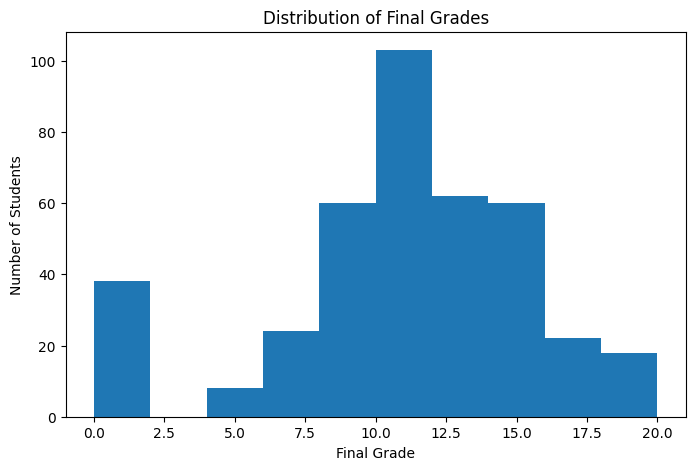

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)

plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()

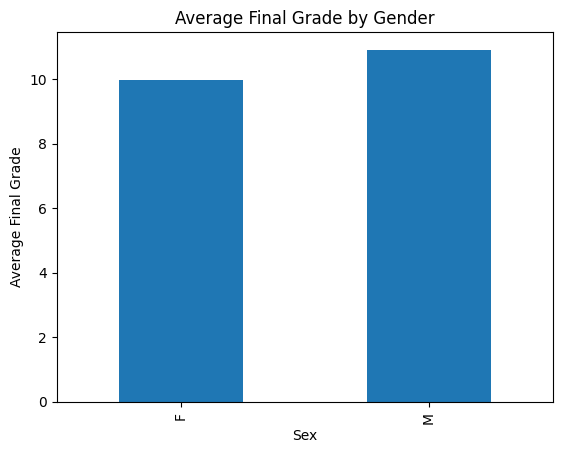

In [ ]:
df.groupby("sex")["G3"].mean().plot(kind="bar")

plt.xlabel("Sex")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")

plt.show()

In [ ]:
df.groupby("studytime")["G3"].mean()

,G3
studytime,
1,10.047619
2,10.171717
3,11.400000
4,11.259259


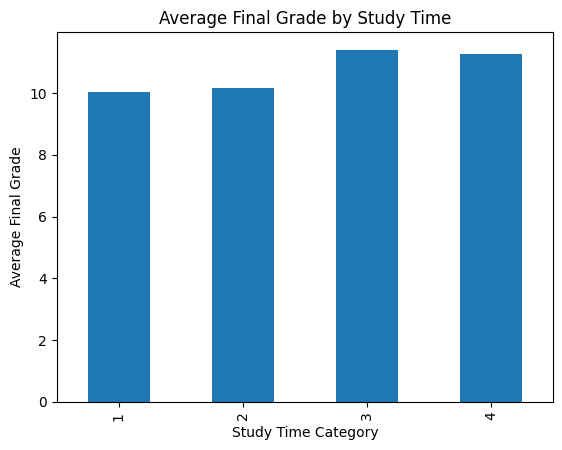

In [ ]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")

plt.show()

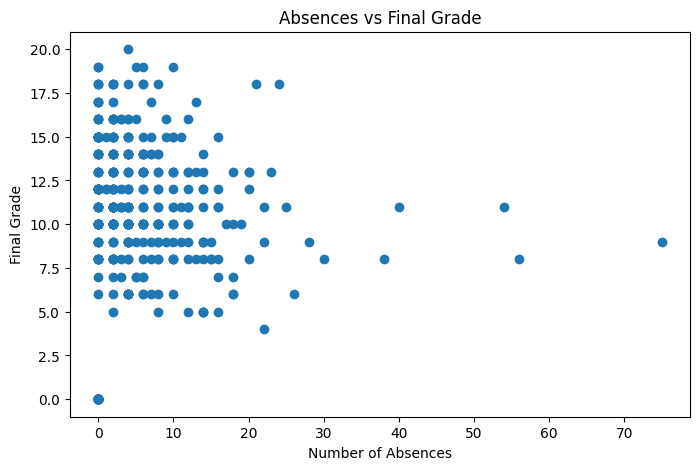

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")

plt.show()

In [ ]:
print(df["absences"].corr(df["G3"]))

0.03424731615006931


In [ ]:
df["pass"] = (df["G3"]>=10).astype(int)

In [ ]:
print(df["pass"].value_counts())

pass
1    265
0    130
Name: count, dtype: int64


In [ ]:
features = [
    "age",
    "studytime",
    "failures",
    "G1",
    "G2"
]

x = df[features]
y = df["pass"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred = model.predict(x_test)

print(y_pred)

[1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0
 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 1 1 0 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8860759493670886


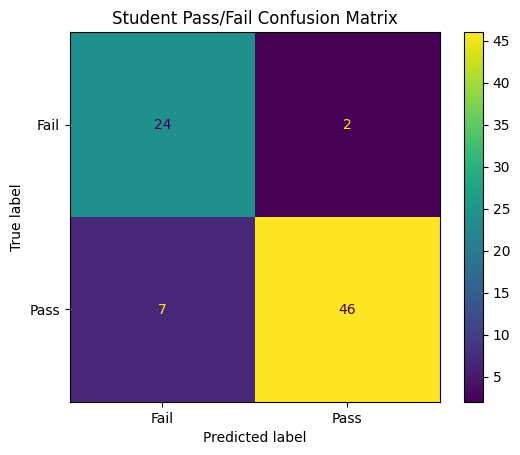

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot()

plt.title ("Student Pass/Fail Confusion Matrix")
plt.show()

**Prediction Results Table**

In [31]:
results = x_test.copy()

results ["Actual"]=y_test
results ["Predicted"]=y_pred

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted
305,18,2,1,14,12,1,1
225,18,2,1,9,8,0,0
237,16,1,0,13,12,1,1
318,17,3,0,11,11,1,1
182,17,2,0,16,17,1,1
94,15,4,0,11,13,1,1
34,16,1,0,12,14,1,1
307,19,1,1,8,9,0,1
33,15,2,0,8,10,1,1
36,15,3,0,15,16,1,1


In [33]:
results ["Recommendation"]= results["Predicted"].map({
    0:"Prioritize for academic intervention",
    1:"Continue regular monitoring"
})

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted,Recommendation
305,18,2,1,14,12,1,1,Continue regular monitoring
225,18,2,1,9,8,0,0,Prioritize for academic intervention
237,16,1,0,13,12,1,1,Continue regular monitoring
318,17,3,0,11,11,1,1,Continue regular monitoring
182,17,2,0,16,17,1,1,Continue regular monitoring
94,15,4,0,11,13,1,1,Continue regular monitoring
34,16,1,0,12,14,1,1,Continue regular monitoring
307,19,1,1,8,9,0,1,Continue regular monitoring
33,15,2,0,8,10,1,1,Continue regular monitoring
36,15,3,0,15,16,1,1,Continue regular monitoring


In [39]:
probabilities = model.predict_proba(x_test)

results ["Probability_of_Failing"]=probabilities[:,0]

results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

,age,studytime,failures,G1,G2,Actual,Predicted,Recommendation,Probability_of_Failing
255,17,1,1,7,9,0,0,Prioritize for academic intervention,1.000000
67,16,4,0,7,7,0,0,Prioritize for academic intervention,1.000000
92,16,2,0,7,6,0,0,Prioritize for academic intervention,1.000000
1,17,2,0,5,5,0,0,Prioritize for academic intervention,1.000000
188,17,2,0,8,7,0,0,Prioritize for academic intervention,1.000000
383,19,1,1,6,5,0,0,Prioritize for academic intervention,1.000000
248,18,2,1,3,5,0,0,Prioritize for academic intervention,1.000000
118,17,2,1,9,7,0,0,Prioritize for academic intervention,1.000000
332,18,2,0,7,0,0,0,Prioritize for academic intervention,1.000000
370,19,2,2,7,7,0,0,Prioritize for academic intervention,1.000000


In [40]:
priority_students=results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

priority_students

,age,studytime,failures,G1,G2,Actual,Predicted,Recommendation,Probability_of_Failing
255,17,1,1,7,9,0,0,Prioritize for academic intervention,1.000000
67,16,4,0,7,7,0,0,Prioritize for academic intervention,1.000000
92,16,2,0,7,6,0,0,Prioritize for academic intervention,1.000000
1,17,2,0,5,5,0,0,Prioritize for academic intervention,1.000000
188,17,2,0,8,7,0,0,Prioritize for academic intervention,1.000000
383,19,1,1,6,5,0,0,Prioritize for academic intervention,1.000000
248,18,2,1,3,5,0,0,Prioritize for academic intervention,1.000000
118,17,2,1,9,7,0,0,Prioritize for academic intervention,1.000000
332,18,2,0,7,0,0,0,Prioritize for academic intervention,1.000000
370,19,2,2,7,7,0,0,Prioritize for academic intervention,1.000000
